In [1]:
import os
import sys
while not os.getcwd().endswith('flocking'):
    os.chdir('..')
    
import numpy as np
from scipy import sparse
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from IPython.display import HTML


In [44]:
class FlockingSimulation:
    def __init__(self, 
                 density: float, 
                 attention_radius: float, 
                 space_size: float, 
                 weights: Dict = {
                     'alignment': 1.0,
                     'cohesion': 0.05,
                     'separation': 0.2
                 },
                 predator_props: Dict = {
                     'min_distance': 0.2,
                     'eat_radius': 0.25,
                     'predator_speed': 1.5
                 },
                 noise: float=0.15,
                 periodic_boundaries: bool=True, 
                 add_predator: bool=False):
        
        self.num_boids = int(density * space_size**2)
        self.attention_radius = attention_radius
        self.space_size = space_size
        self.weights = weights
        self.periodic_boundaries = periodic_boundaries
        self.noise = noise
        self.add_predator = add_predator
        self.min_distance = predator_props['min_distance']
        self.eat_radius = predator_props['eat_radius']
        self.predator_speed = predator_props['predator_speed']

        self.initialize_boids()
    
    def initialize_boids(self):
        pos = np.random.rand(self.num_boids, 2) * self.space_size
        vel = (np.random.rand(self.num_boids, 2) - 0.5) * 10
        self.pos = pos
        self.vel = vel
        
        if self.add_predator:
            self.pred_pos = np.random.rand(2) * self.space_size
            self.pred_vel = (np.random.rand(2) - 0.5) * 10
        
        

    def update(self, dt=1.0):

        tree = cKDTree(self.pos, boxsize=[self.space_size, self.space_size])
        dist = tree.sparse_distance_matrix(
            tree,
            max_distance=self.attention_radius,
            output_type="coo_matrix"
        )

        row = dist.row
        col = dist.col

        N = self.num_boids

        counts = np.bincount(row, minlength=N)
        counts[counts == 0] = 1
        # --------------------
        # ALIGNMENT
        # --------------------

        data_x = self.vel[col,0]
        data_y = self.vel[col,1]

        Mx = sparse.coo_matrix((data_x,(row,col)), shape=(N,N))
        My = sparse.coo_matrix((data_y,(row,col)), shape=(N,N))

        align_x = np.asarray(Mx.tocsr().sum(axis=1)).flatten()
        align_y = np.asarray(My.tocsr().sum(axis=1)).flatten()

        alignment = np.column_stack((align_x,align_y)) / counts[:,None]


        # --------------------
        # COHESION
        # --------------------

        diff = self.pos[col] - self.pos[row]
        diff -= self.space_size * np.round(diff / self.space_size)

        Mx = sparse.coo_matrix((diff[:,0],(row,col)), shape=(N,N))
        My = sparse.coo_matrix((diff[:,1],(row,col)), shape=(N,N))

        coh_x = np.asarray(Mx.tocsr().sum(axis=1)).flatten()
        coh_y = np.asarray(My.tocsr().sum(axis=1)).flatten()

        cohesion = np.column_stack((coh_x,coh_y)) / counts[:,None]

        # --------------------
        # SEPARATION
        # --------------------

        diff = self.pos[row] - self.pos[col]
        diff -= self.space_size * np.round(diff / self.space_size)

        dist2 = np.sum(diff**2, axis=1) + 1e-6
        dist = np.sqrt(dist2)

        # stronger repulsion if too close
        strength = np.where(dist < self.min_distance,
                            10 / dist2,
                            1 / dist2)

        sep = diff * strength[:,None]

        Mx = sparse.coo_matrix((sep[:,0],(row,col)), shape=(N,N))
        My = sparse.coo_matrix((sep[:,1],(row,col)), shape=(N,N))

        sep_x = np.asarray(Mx.tocsr().sum(axis=1)).flatten()
        sep_y = np.asarray(My.tocsr().sum(axis=1)).flatten()

        separation = np.column_stack((sep_x,sep_y)) / counts[:,None]

        # --------------------
        # COMBINE DIRECTIONS
        # --------------------

        desired = (
            self.weights["alignment"] * alignment +
            self.weights["cohesion"] * cohesion +
            self.weights["separation"] * separation
        )
        
        if self.add_predator:
            pred_diff = self.pos - self.pred_pos
            pred_diff -= self.space_size * np.round(pred_diff / self.space_size)

            pred_dist2 = np.sum(pred_diff**2, axis=1) + 1e-6
            avoid = pred_diff / pred_dist2[:,None]

            desired += 2.0 * avoid
    


        # --------------------
        # NORMALIZE (Vicsek rule)
        # --------------------

        norm = np.linalg.norm(desired, axis=1) + 1e-8
        desired /= norm[:,None]


        # --------------------
        # ADD ANGULAR NOISE
        # --------------------

        theta = np.arctan2(desired[:,1], desired[:,0])
        theta += self.noise * np.random.uniform(-np.pi, np.pi, size=N)

        self.vel[:,0] = np.cos(theta)
        self.vel[:,1] = np.sin(theta)


        # constant speed
        speed = 1.0
        self.vel *= speed


        # --------------------
        # MOVE
        # --------------------

        self.pos += self.vel * dt
        self.pos %= self.space_size
        
        if self.add_predator:

            # vector predator -> boids
            diff = self.pos - self.pred_pos
            diff -= self.space_size * np.round(diff / self.space_size)

            dist = np.linalg.norm(diff, axis=1)

            # normalized direction vectors to boids
            dir_vec = diff / (dist[:,None] + 1e-8)

            # predator forward direction
            pred_dir = self.pred_vel / (np.linalg.norm(self.pred_vel) + 1e-8)

            # dot product: which boids are in front
            forwardness = dir_vec @ pred_dir
            mask = forwardness > 0.5

            # choose closest prey in front
            if np.any(mask):
                idx = np.argmin(dist + (~mask)*1e6)
                target = diff[idx]

                target /= np.linalg.norm(target) + 1e-8

                # smooth pursuit (optional but better)
                self.pred_vel = 0.8*self.pred_vel + 0.2*target

            # enforce constant predator speed
            self.pred_vel /= np.linalg.norm(self.pred_vel) + 1e-8
            self.pred_vel *= self.predator_speed


            # move predator
            self.pred_pos += self.pred_vel * dt
            self.pred_pos %= self.space_size


            # check eating AFTER movement
            diff = self.pos - self.pred_pos
            diff -= self.space_size * np.round(diff / self.space_size)

            dist = np.linalg.norm(diff, axis=1)
            eaten = dist < self.eat_radius

            if np.any(eaten):
                self.pos = self.pos[~eaten]
                self.vel = self.vel[~eaten]
                self.num_boids = len(self.pos)
        
    def plot(self):
        plt.figure(figsize=(8,8), dpi=96)
        plt.quiver(self.pos[:,0], self.pos[:,1], self.vel[:,0], self.vel[:,1], angles='xy', scale_units='xy', scale=1)
        plt.xlim(0, self.space_size)
        plt.ylim(0, self.space_size)
        # plt.title('Boid Flocking Simulation')
        # plt.xlabel('X')
        # plt.ylabel('Y')
        plt.grid()
        plt.show()
    
    def animate(self, steps=100, interval=100):
        from matplotlib import animation

        fig, ax = plt.subplots(figsize=(8,8), dpi=96)
        fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99)
        
        if self.add_predator:
            pred_plot = ax.scatter(
                [self.pred_pos[0]],
                [self.pred_pos[1]],
                color="red",
                s=80,
                marker="X"
            )
        
        theta = np.arctan2(self.vel[:,1], self.vel[:,0])
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')
        quiver = ax.quiver(
            self.pos[:,0], self.pos[:,1],
            self.vel[:,0], self.vel[:,1],
            theta,
            angles='xy',
            scale_units='xy',
            scale=1,
            clim=[-np.pi, np.pi],
            cmap='hsv'
        )
        ax.set_xlim(0, self.space_size)
        ax.set_ylim(0, self.space_size)
        ax.margins(0.0)
        # ax.set_title('Boid Flocking Simulation')
        # ax.set_xlabel('X')
        # ax.set_ylabel('Y')
        # ax.grid('false')
        # ax.set_aspect('equal')
        ax.set_axis_off()

        def update(frame):
            self.update()
            quiver.set_offsets(self.pos)
            theta = np.arctan2(self.vel[:,1], self.vel[:,0])
            quiver.set_UVC(self.vel[:,0], self.vel[:,1], theta)
            if self.add_predator:
                pred_plot.set_offsets(self.pred_pos)
                return quiver, pred_plot
            return quiver,
        
        anim = animation.FuncAnimation(fig, update, frames=steps, interval=interval, blit=True)
        anim.save('flocking_animation.gif', writer='pillow')
        plt.show()
        
    def run(self, steps=100, viz_mode: str ="plot", plot_interval: int =10):
        if viz_mode == "plot":
            for step in range(steps):
                self.update()
                if step % plot_interval == 0:
                    self.plot()
        elif viz_mode == "animate":
            self.animate(steps=steps, interval=100)

In [45]:
model = FlockingSimulation(density=0.3, attention_radius=4., space_size=64.0,
                           weights={
                             'alignment': 1.0,
                             'cohesion': 0.025,
                             'separation': 0.2
                         },
                          predator_props={
                             'min_distance': 0.2,
                             'eat_radius': 0.25,
                             'predator_speed': 1.5
                         },
                         noise=0.15,
                         periodic_boundaries=True,
                         add_predator=True)

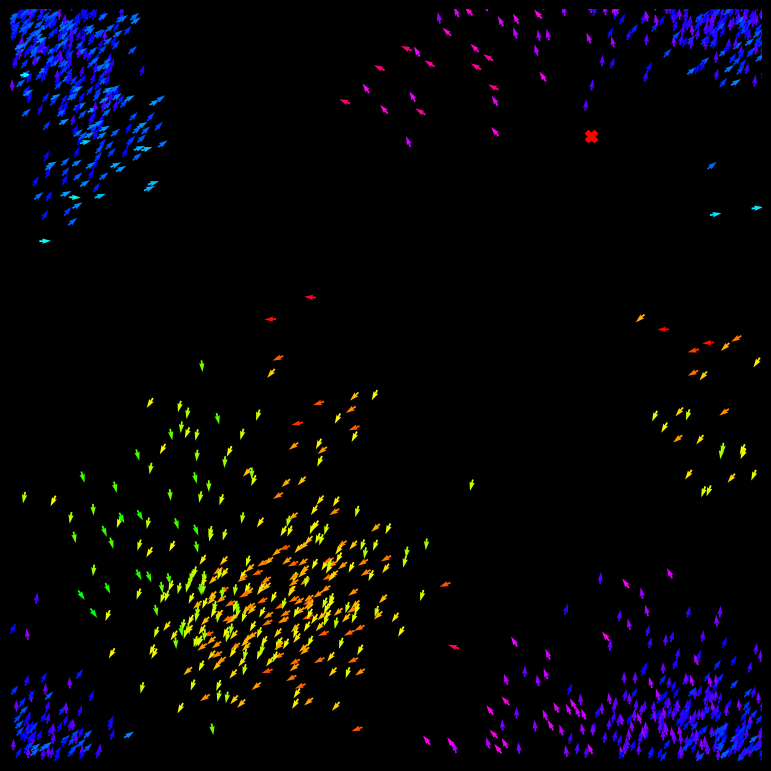

In [46]:
model.run(steps=200, viz_mode="animate")